In [106]:
import pandas as pd
import geopandas as gpd
import xarray as xr
import numpy as np

import string
import windrose
import matplotlib.pyplot as plt
from matplotlib.colors import BoundaryNorm
from matplotlib.patches import Rectangle
from mpl_toolkits.axes_grid1 import make_axes_locatable
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

from metpy.calc import wind_components,wind_direction,wind_speed
from metpy.units import units

from cmcrameri import cm

plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = [
    'Helvetica',
    'Nimbus Sans',
    'Arial',
    'Liberation Sans'
]

data_dir = '../data/' 
fig_png_dir = '../figures_png/'
fig_pdf_dir = '../figures_pdf/'

In [147]:
def get_df_from_nc(file, var, loc_sel=None):
    ds = xr.open_dataset(file)
    time_dim = ds[var].dims[0]
    df = pd.DataFrame(ds[var].values, columns=ds.location, index=pd.to_datetime(ds[time_dim],utc=True))
    if loc_sel is None:
        return df
    else:
        return df[loc_sel]

def get_mean_timeframe(str_from, str_to):
    def add_to_output(df_in, mask, col_name):
        s_cnt = df_in.where(mask)[dt_from:dt_to].count()
        s_mean = df_in.where(mask)[dt_from:dt_to].mean()
        s_mean[s_cnt<12]=np.nan
        s_mean.name = col_name
        return pd.merge(df_out, s_mean, left_on='loc', right_index=True, how='left')
        
    dt_from = pd.to_datetime(str_from, utc=True)
    dt_to   = pd.to_datetime(str_to, utc=True)

    df_out = df_loc.copy()
    
    df_out = add_to_output(df_temp,   temp_mask, 'temp_o')
    df_out = add_to_output(df_i_temp, temp_mask, 'temp_i')

    df_out = add_to_output(df_u,   wind_mask, 'u_o')
    df_out = add_to_output(df_v,   wind_mask, 'v_o')
    df_out = add_to_output(df_i_u, wind_mask, 'u_i')
    df_out = add_to_output(df_i_v, wind_mask, 'v_i')
    
    return df_out


#get_mean_timeframe('2023-08-20', '2023-08-25')
#get_mean_timeframe('2023-08-29', '2023-08-30')
#df_data = get_mean_timeframe('2023-09-04', '2023-09-07')

#df_data

## Script settings

In [132]:
loc_temp = ['D316','A309','D305','T303','D293','D285','D281','T275','D269','A267','A267R','A267L','A260','A255','STHE']
loc_wind = ['D316','A309','T303', 'D293', 'D281','T275','D269','A267','A267L','A267R','A260','A255', 'STHE' ]

use_avg_wind = True

## Read data

In [133]:
# get outline of Hintereisferner (HEF)
rgi = gpd.read_file('/work/bb1461/shp/Glacier_Outlines_v370_2030_smoothed.geojson')
rgi_hef = rgi.loc[rgi['rgi_id'] == 'RGI60-11.00897']

In [134]:
# get locations with coords
ds = xr.open_dataset(data_dir + f'H2_Observations_stations.nc')

df_loc = pd.DataFrame()
df_loc['loc'] = ds.location.values
df_loc['lon'] = ds.lon.values
df_loc['lat'] = ds.lat.values

In [142]:
# get temp data
df_temp   = get_df_from_nc(data_dir + f'H2_Observations_stations.nc',   't_2m')
df_i_temp = get_df_from_nc(data_dir + f'H2_ICON_v370_2030_stations.nc', 't_5m') - 273.15

# get wind vectors (surface)
if use_avg_wind: 
    avg_suf = '_avg'  # get 30min avg wind
else: 
    avg_suf = ''      # inst wind at full hour
    
df_u = get_df_from_nc(data_dir + f'H2_Observations_stations.nc', f'u{avg_suf}')
df_v = get_df_from_nc(data_dir + f'H2_Observations_stations.nc', f'v{avg_suf}')

df_i_u = get_df_from_nc(data_dir + f'H2_ICON_v370_2030_stations.nc', f'u_5m{avg_suf}') 
df_i_v = get_df_from_nc(data_dir + f'H2_ICON_v370_2030_stations.nc', f'v_5m{avg_suf}') 

# get wind vectors at 500hPa level (over T275 location) and calculate wind speed & direction
df_i_u_syn = get_df_from_nc(data_dir + f'H2_ICON_v370_2030_stations.nc', 'u_500hPa', ['T275']) 
df_i_v_syn = get_df_from_nc(data_dir + f'H2_ICON_v370_2030_stations.nc', 'v_500hPa', ['T275']) 

df_500 = pd.DataFrame(index=df_i_u_syn.index)
df_500['ws'] = wind_speed(df_i_u_syn['T275'].values * units('m/s'), df_i_v_syn['T275'].values * units('m/s'))
df_500['wd'] = wind_direction(df_i_u_syn['T275'].values * units('m/s'), df_i_v_syn['T275'].values * units('m/s'))

# get masks for valid records (= Observation and ICON data available)
temp_mask = df_temp.notna() & df_i_temp.notna()
wind_mask = df_u.notna() & df_v.notna() & df_i_u.notna() & df_i_v.notna()

In [180]:
def add_minmax_text(ax, s):
    ax.text(0.01, 0.90, 
            fr"$T_{{min}}={s.min():.2f}$ °C"
            "\n"
            fr"$T_{{max}}={s.max():.2f}$ °C", 
            transform=ax.transAxes,
            fontsize=8, ha="left", va="top")

def add_daterange_text(ax, date_range_str):
    ax.text(0.01,0.99, date_range_str,transform=ax.transAxes,ha="left", va="top")
    rect = Rectangle(
        (0.00, 1-.06 ),0.25, 0.06,
        transform=ax.transAxes,
        edgecolor="black",facecolor="whitesmoke",lw=.5
    )
    ax.add_patch(rect)

def plot_maps(ax_o, ax_i, str_from, str_to):        
    def add_data_and_text(ax, col_temp, col_u, col_v):
        add_daterange_text(ax, date_range_str)
        add_minmax_text(ax, df_temp[col_temp])
        ax.scatter(df_temp['lon'], df_temp['lat'], c=df_temp[col_temp], cmap=cmap, norm=norm, s=16)
        ax.barbs(df_wind['lon'], df_wind['lat'], df_wind[col_u], df_wind[col_v], barb_increments=bi, length=4.5, lw=.5, pivot='tip')
    
    dt_from = pd.to_datetime(str_from, utc=True)
    dt_to   = pd.to_datetime(str_to, utc=True)
    
    # get plot data (filtering on given time frame and selected locations for temp/wind)
    date_range_str = dt_from.strftime('%d.-') + dt_to.strftime('%d. %b %Y')
    print(date_range_str)
    df_data = get_mean_timeframe(str_from, str_to)
    df_temp = df_data[df_data['loc'].isin(loc_temp)]
    df_wind = df_data[df_data['loc'].isin(loc_wind)]
    df_500_tmp = df_500.loc[dt_from:dt_to]

    #-- Left Panel
    # Observation Data
    add_data_and_text(ax_o, 'temp_o', 'u_o', 'v_o')
    
    # Barb Legend
    ax = ax_o
    bi_legend = [0]+list(bi.values())
    lon = np.repeat(10.788, 4)
    lat = np.arange(46.792,46.785,-.002)
    ax.text(10.798, lat[0]+.002, 'Wind barbs',ha='right',va='center',fontsize=8, weight='bold')
    ax.barbs(lon, lat, bi_legend, [0,0,0,0], barb_increments=bi, length=4.5, lw=.5, pivot='middle')
    for i,b in enumerate(bi_legend):
        if i == 0: ax.text(10.798, lat[i], f'<{bi_legend[1]} m/s',ha='right',va='center',fontsize=8)  # circle (lower than half barb)
        else: ax.text(10.798, lat[i], f'{b:.1f} m/s',ha='right',va='center',fontsize=8)               # barb increment values
    
    #-- Right Panel
    # ICON Data
    add_data_and_text(ax_i, 'temp_i', 'u_i', 'v_i')
    ax=ax_i
    
    # Plot the windrose on additional axis
    wrax = inset_axes(
        ax, width=.9, height=.9,
        loc="lower right", bbox_to_anchor=(10.7985, 46.785), 
        bbox_transform=ax.transData,  
        axes_class=windrose.WindroseAxes,  
    )           
    wrax.bar(df_500_tmp.wd, df_500_tmp.ws, normed=True, opening=0.9, cmap=cm.acton)
    wrax.grid(alpha=.3)
    wrax.grid(axis='y')
    wrax.tick_params(labelleft=False, labelbottom=True, labelsize=6, pad=-5)
    wrax.set_title('500 hPa level', fontsize=8)

20.-25. Aug 2023
29.-30. Aug 2023
04.-07. Sep 2023


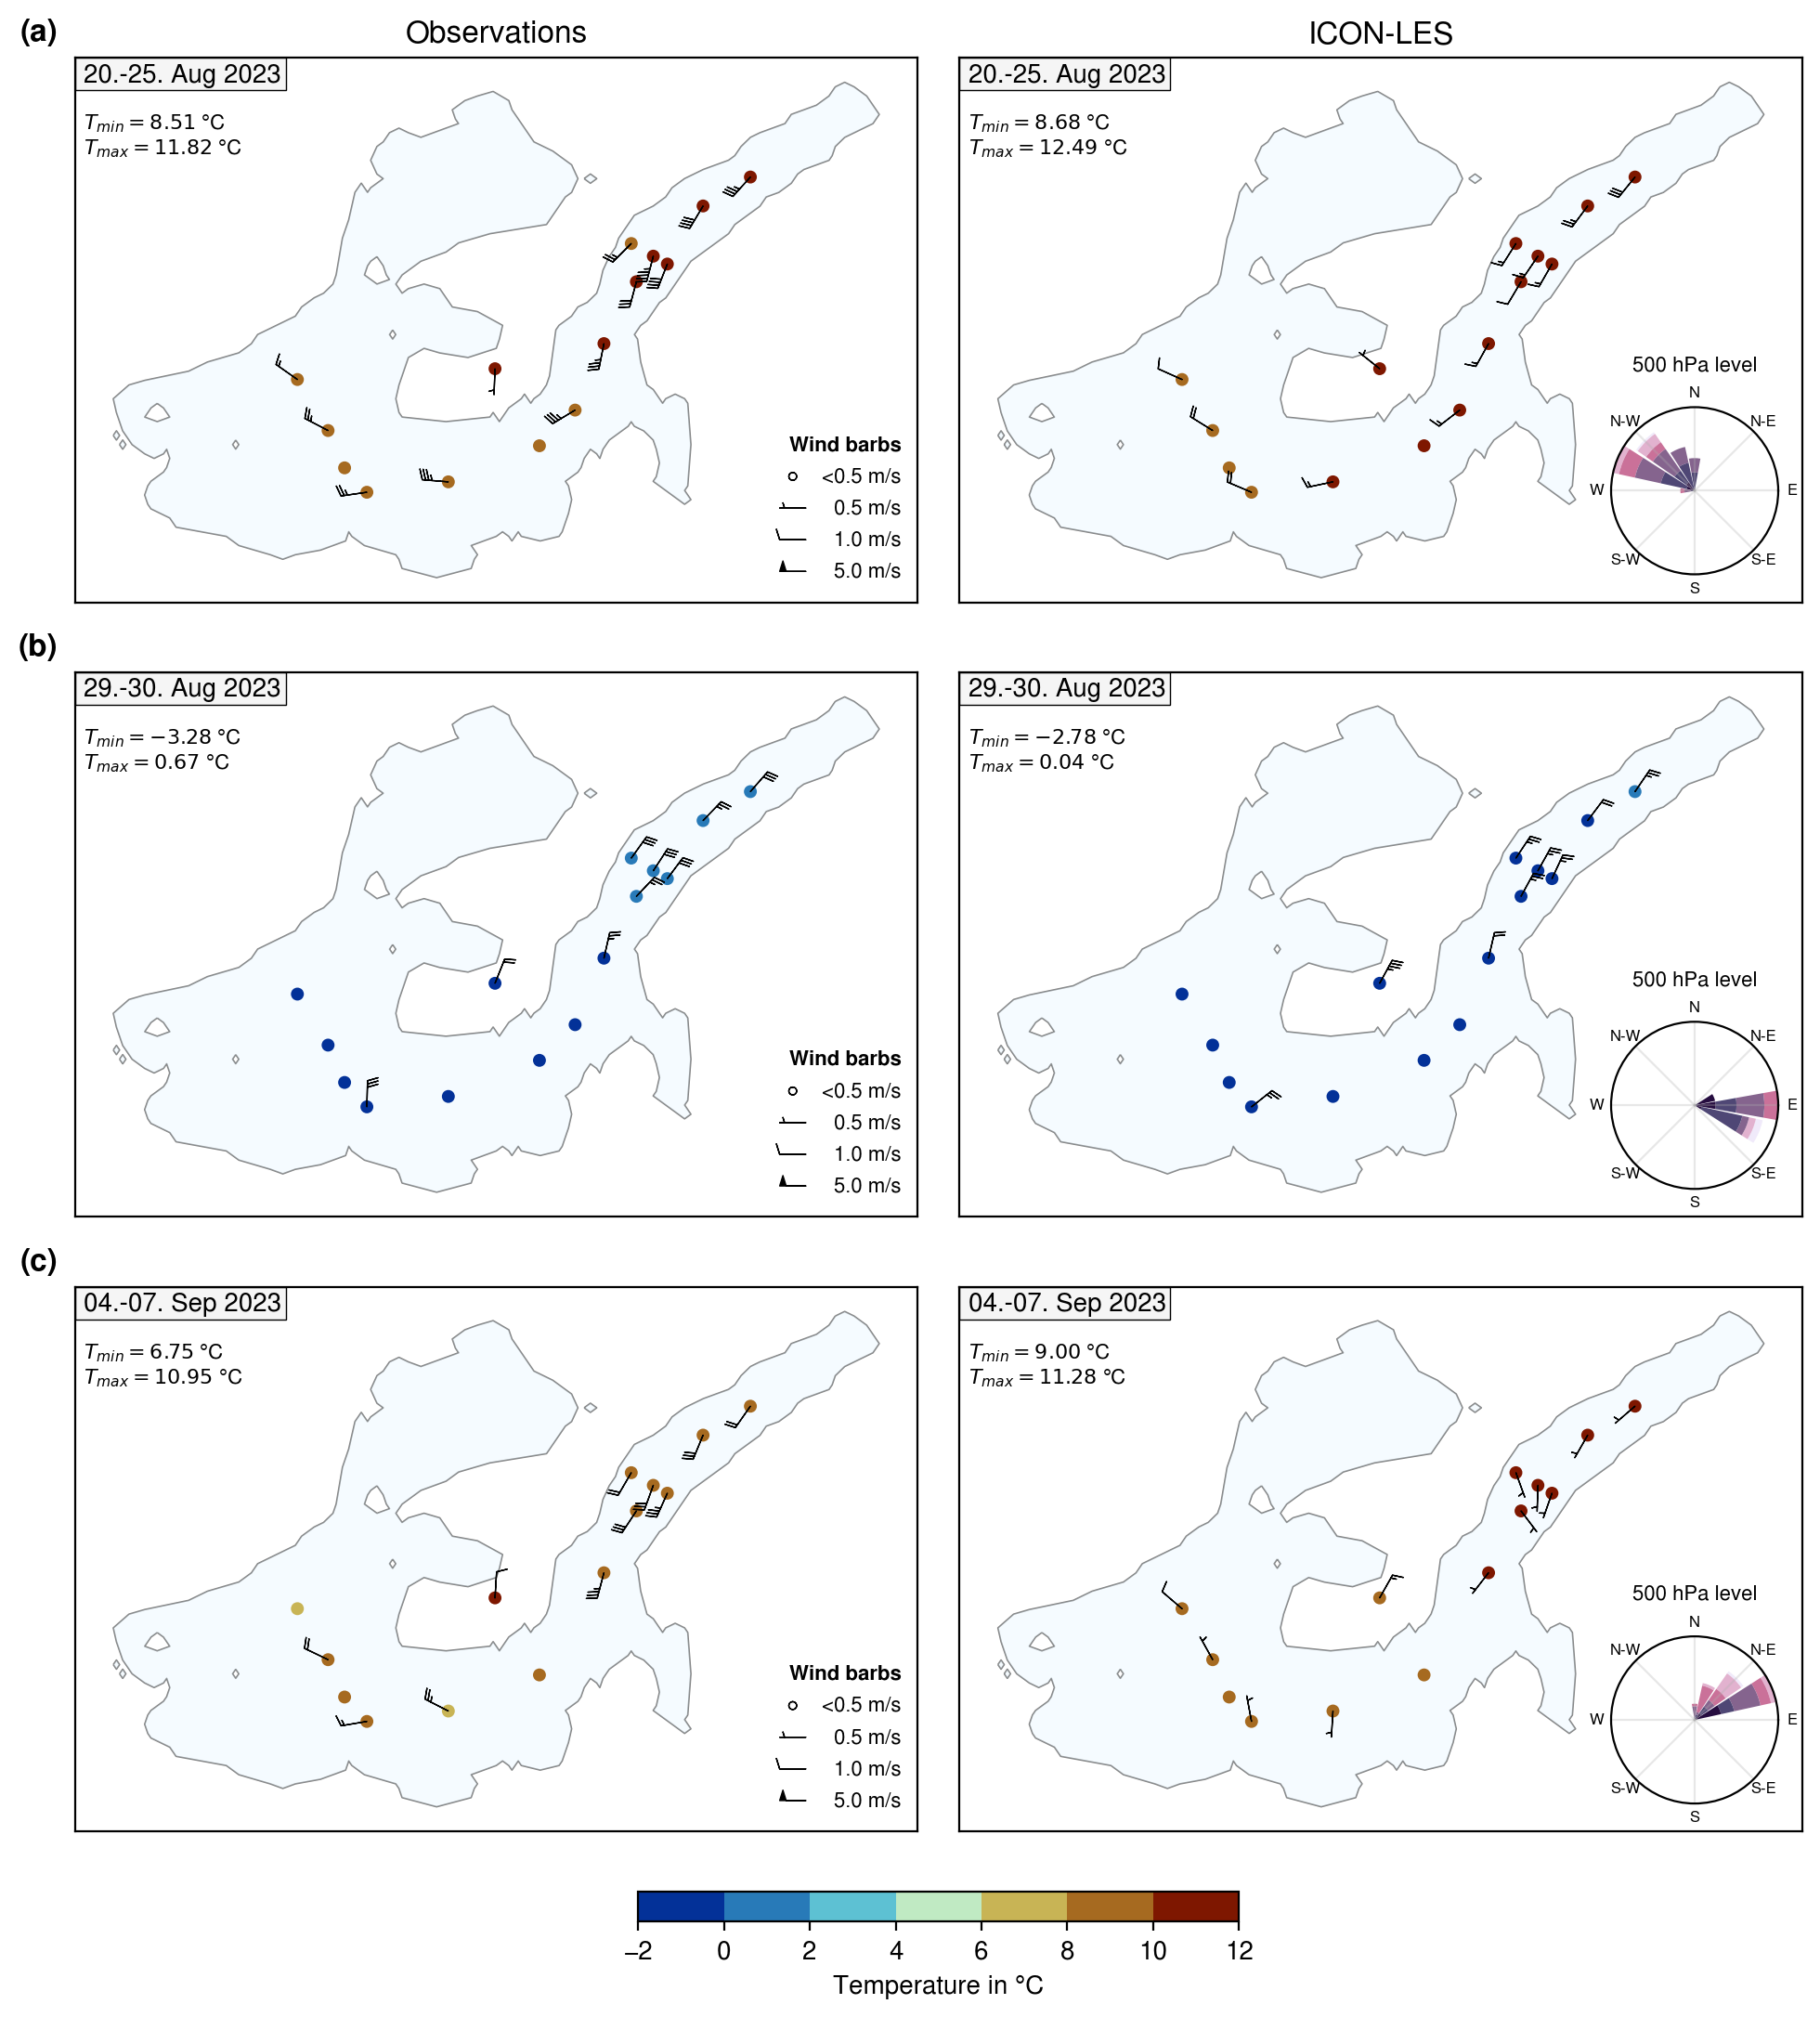

In [182]:
#bi = dict(half=2.57222, full=5.144, flag=25.7222)
#bi = dict(half=1, full=2, flag=10)
bi = dict(half=.5, full=1, flag=5)

bounds = range(-2,14,2) #[5,6,7,8,9,10]
cmap = plt.get_cmap(cm.roma_r, len(bounds)-1)  # discrete viridis
norm = BoundaryNorm(bounds, cmap.N)

fig, axs = plt.subplots(ncols=2, nrows=3, figsize=(12,14), sharex=True, sharey=True, dpi=200,
                        gridspec_kw={'hspace': -0.1, 'wspace': 0.05})

# base map with glacier
for ax in axs.flatten():
    rgi_hef.boundary.plot(ax=ax, lw=.6, color='grey', zorder=-10)
    rgi_hef.plot(ax=ax, color='#d9f0ff',alpha=.25)

# data for defined time frames
plot_maps(axs[0][0], axs[0][1], '2023-08-20', '2023-08-25')
plot_maps(axs[1][0], axs[1][1], '2023-08-29', '2023-08-30')
plot_maps(axs[2][0], axs[2][1], '2023-09-04', '2023-09-07')

# add column titles
axs[0][0].set_title('Observations')
axs[0][1].set_title('ICON-LES')

# remove tick labels
for ax in axs.flat:
    ax.set_xticks([])
    ax.set_yticks([])


#fig.colorbar(plt.cm.ScalarMappable(norm=norm, cmap=cmap), cax=cax, label='Temp. in °C')
cbar = fig.colorbar(
    plt.cm.ScalarMappable(norm=norm, cmap=cmap),
    label='Temperature in °C',
    ax=axs.ravel(),          # attach to ALL subplots
    orientation='horizontal',
    fraction=0.015,            # size of the colorbar
    pad=0.03                  # distance from subplots
)

# panel letters 
for ax, letter in zip(axs[:, 0], string.ascii_lowercase):
    ax.text(
        -0.02, 1.02, f'({letter})',
        transform=ax.transAxes,
        fontsize=12, fontweight='bold',
        va='bottom', ha='right'
    )

# save and show
plt.savefig(fig_png_dir + f'HEF_Obs_ICON_windmap.png', dpi=150, bbox_inches = 'tight', pad_inches = 0)
plt.savefig(fig_pdf_dir + f'HEF_Obs_ICON_windmap.pdf', dpi=300, bbox_inches = 'tight', pad_inches = 0)
plt.show()

## ---

[5, 0.5, 1, 5]